## 1. Data Exploration | Sherry

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/drive/MyDrive/top_50_stocks_data_formatted.csv')

In [16]:
# find daily return
df["Daily Return"] = df.groupby("Ticker")["Adjusted Close"].pct_change()

#find annualized return
annual_return = df.groupby("Ticker")["Daily Return"].mean() * 252

#find annual volatility
annual_volatility = df.groupby("Ticker")["Daily Return"].std() * np.sqrt(252)

#find sharpe ratio
sharpe_ratio = annual_return / annual_volatility

NameError: name 'df' is not defined

In [ ]:
#combine
metrics_df = pd.DataFrame({
    "Annualized Return": annual_return,
    "Annualized Volatility": annual_volatility,
    "Sharpe Ratio": sharpe_ratio
})

metrics_df.head()

In [ ]:
#plot histograms

plt.figure(figsize=(18,5))

# Annualized Return
plt.subplot(1,3,1)
sns.histplot(metrics_df["Annualized Return"], bins=10, kde=True)
plt.title("Annualized Return")

# Annualized Volatility
plt.subplot(1,3,2)
sns.histplot(metrics_df["Annualized Volatility"], bins=10, kde=True)
plt.title("Annualized Volatility")

# Sharpe Ratio
plt.subplot(1,3,3)
sns.histplot(metrics_df["Sharpe Ratio"], bins=10, kde=True)
plt.title("Sharpe Ratio")

plt.tight_layout()
plt.show()

In [ ]:
#analyze correlations
correlation = metrics_df.corr()

#heatmap
sns.heatmap(metrics_df.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap of Annualized Return, Annualized Volatility, and Sharpe Ratio")
plt.show()

In [ ]:
#Explain findings
#The heatmap shows the correlations between annualized return,
# annualized volatility, and Sharpe ratio. Annualized return has
# a strong positive correlation with the Sharpe ratio, indicating
# that stocks with higher returns generally have better risk-adjusted
# performance. Annualized volatility has a weak negative correlation
# with the Sharpe ratio, suggesting that higher volatility does not
# necessarily lead to better risk-adjusted returns.


#Should any other variables be added based on the entire dataset?
#Yes. We added Average Price Change and Average Volume.
# Average Price Change reflects a stock's average daily movement,
# while Average Volume measures trading activity and liquidity.
# So, including these variables provides more information about stock
# behavior and may improve future clustering and stock recommendations.

In [ ]:
#Adding other variables to dataset and heatmap
metrics_df["Average Volume"] = df.groupby("Ticker")["Volume"].mean()
metrics_df["Average Price Change"] = df.groupby("Ticker")["Close"].mean() - df.groupby("Ticker")["Open"].mean()

#new heatmap
sns.heatmap(metrics_df.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap with Additional Variables")
plt.show()

## 2 & 3. Model Enhancement | Felix | & | User Interaction and Feedback | Tasuto

Enter stock tickers separated by commas: AMZN, APPL

Processing AMZN...


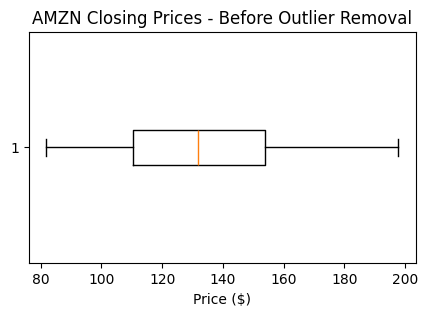

Training LSTM Neural Network...
ARIMA MAPE for AMZN: 1.81%
LSTM MAPE for AMZN:  3.65%
-> For AMZN, ARIMA was the more suitable/accurate model.


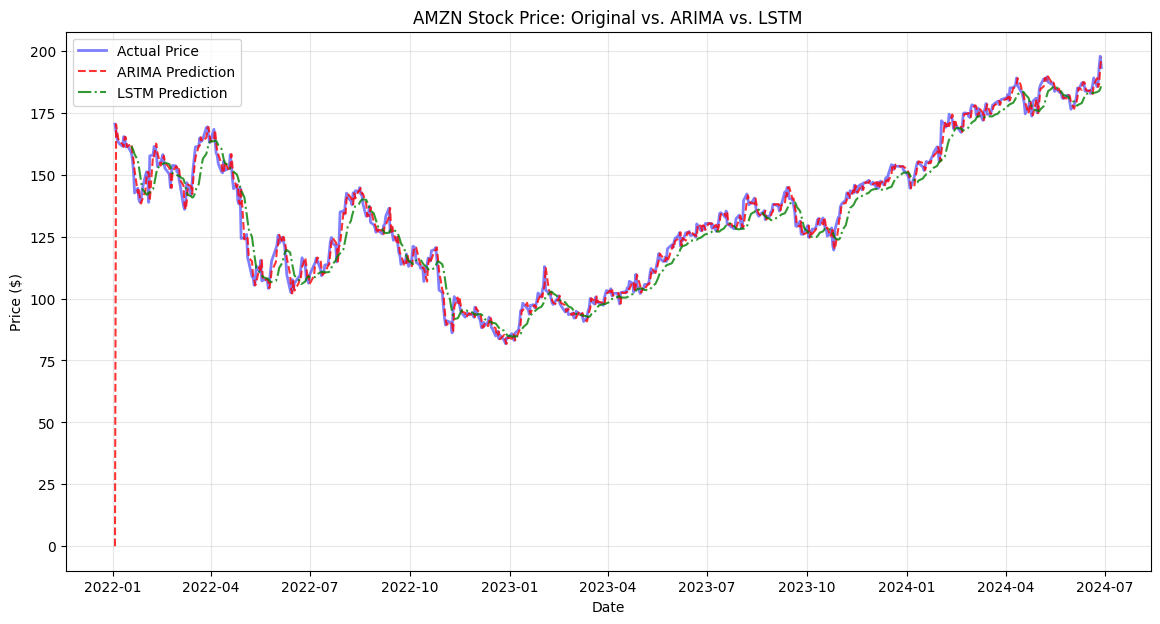


Processing APPL...


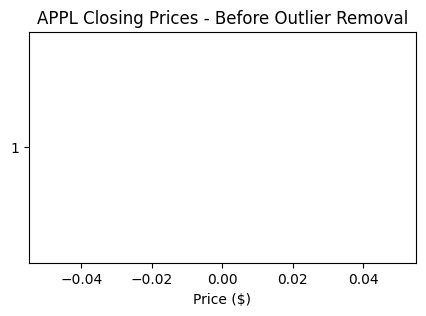

No data found for APPL


In [17]:
#
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_percentage_error
import warnings

# --- NEW IMPORTS ADDED HERE ---
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf

# Setting random seeds for reproducibility in the neural network
tf.random.set_seed(42)
np.random.seed(42)
# ------------------------------

warnings.filterwarnings("ignore")

def process_stock_data(ticker_symbol, start, end, csv_file='top_50_stocks_data_formatted.csv'):
    """
    Reads the CSV and filters for the specific ticker and date range.
    Expected CSV columns: Ticker, Date, Close
    """
    df = pd.read_csv(csv_file)
    # Convert Date to datetime object
    df['Date'] = pd.to_datetime(df['Date'])

    # Filter by ticker and date
    mask = (
        (df['Ticker'] == ticker_symbol) &
        (df['Date'] >= start) &
        (df['Date'] <= end)
    )
    ticker_df = df.loc[mask].sort_values('Date')
    # Display box plot
    plt.figure(figsize=(5, 3))
    plt.boxplot(ticker_df['Close'], vert=False)
    plt.title(f'{ticker_symbol} Closing Prices - Before Outlier Removal')
    plt.xlabel('Price ($)')
    plt.show()
    #Outlier Detection
    Q1 = ticker_df['Close'].quantile(0.25)
    Q3 = ticker_df['Close'].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)
    # Remove outliers
    ticker_df = ticker_df[
        (ticker_df['Close'] >= lower_bound) &
        (ticker_df['Close'] <= upper_bound)
    ]
    # Set Date as index
    ticker_df.set_index('Date', inplace=True)

    return ticker_df['Close']


def arima_model(data, order=(5, 1, 0)):
    """
    Fits ARIMA model and returns predictions.
    Default order (5,1,0) is common for daily stock data.
    """
    # Fit ARIMA and get fitted values (in-sample)
    model = ARIMA(data, order=order)
    model_fit = model.fit()

    # Return fitted values for comparison
    return model_fit.fittedvalues

def compute_mape(actual, predicted):
    """
    Computes the Mean Absolute Percentage Error.
    """
    # Filter out the first element because differencing (d=1) creates a 0/NaN there
    return np.round(mean_absolute_percentage_error(actual[1:], predicted[1:]) * 100, 2)

def plot_data(actual, predicted, title):
    """
    Plots the actual vs predicted values.
    """
    plt.figure(figsize=(12, 6))
    plt.plot(actual, label='Actual Price', color='blue', alpha=0.6)
    plt.plot(predicted, label='ARIMA Prediction', color='red', linestyle='--')
    plt.title(title)
    plt.xlabel('Date')
    plt.ylabel('Price ($)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# --- NEW FUNCTIONS ADDED HERE ---
def lstm_model(data, look_back=10):
    """
    Fits an LSTM Neural Network model and returns predictions.
    """
    # Scale data to values between 0 and 1 (highly recommended for NNs)
    scaler = MinMaxScaler(feature_range=(0, 1))
    dataset = data.values.reshape(-1, 1)
    scaled_data = scaler.fit_transform(dataset)

    # Create sequential dataset with a look_back window
    X, Y = [], []
    for i in range(len(scaled_data) - look_back):
        X.append(scaled_data[i:(i + look_back), 0])
        Y.append(scaled_data[i + look_back, 0])
    X, Y = np.array(X), np.array(Y)

    # Reshape input to be [samples, time steps, features] required for LSTM
    X = np.reshape(X, (X.shape[0], X.shape[1], 1))

    # Build the LSTM network
    model = Sequential()
    model.add(LSTM(50, return_sequences=True, input_shape=(look_back, 1)))
    model.add(LSTM(50, return_sequences=False))
    model.add(Dense(25))
    model.add(Dense(1))

    # Compile and train
    model.compile(optimizer='adam', loss='mean_squared_error')
    # Using low epochs for speed in testing; increase for better real-world accuracy
    model.fit(X, Y, batch_size=16, epochs=10, verbose=0)

    # Generate predictions and inverse transform to get actual prices
    predictions = model.predict(X, verbose=0)
    predictions = scaler.inverse_transform(predictions)

    # Pad the beginning of the predictions array with NaNs to align with original dates
    padded_predictions = np.empty_like(dataset)
    padded_predictions[:] = np.nan
    padded_predictions[look_back:] = predictions

    return padded_predictions.flatten()

def compute_lstm_mape(actual, predicted, look_back=10):
    """
    Computes MAPE specifically for LSTM, ignoring the initial NaN padded values.
    """
    actual_array = actual.values
    return np.round(mean_absolute_percentage_error(actual_array[look_back:], predicted[look_back:]) * 100, 2)

def plot_comparison_data(actual, arima_pred, lstm_pred, title):
    """
    Plots the actual vs ARIMA predicted vs LSTM predicted values.
    """
    plt.figure(figsize=(14, 7))
    plt.plot(actual.index, actual.values, label='Actual Price', color='blue', alpha=0.5, linewidth=2)
    plt.plot(actual.index, arima_pred, label='ARIMA Prediction', color='red', linestyle='--', alpha=0.8)
    plt.plot(actual.index, lstm_pred, label='LSTM Prediction', color='green', linestyle='-.', alpha=0.8)
    plt.title(title)
    plt.xlabel('Date')
    plt.ylabel('Price ($)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
# --------------------------------

# --- MAIN EXECUTION LOOP ---

# Ask user for tickers
user_input = input("Enter stock tickers separated by commas: ")

# Adjust tickers to binto a clean list of uppercase tickers
tickers = [ticker.strip().upper() for ticker in user_input.split(",") if ticker.strip()]

# Adjusting dates based on your actual CSV bounds ('2022-01-03' to '2024-06-28')
start_date = '2022-01-03'
end_date = '2024-06-28'

for ticker in tickers:
    try:
        print(f"\nProcessing {ticker}...")

        # Step 1: Get closing prices
        closing_prices = process_stock_data(ticker, start_date, end_date)

        if closing_prices.empty:
            print(f"No data found for {ticker}")
            continue

        # Step 2: Fit ARIMA model and get predictions
        arima_predictions = arima_model(closing_prices)

        # Step 2b: Fit LSTM model and get predictions (NEW)
        print("Training LSTM Neural Network...")
        lstm_predictions = lstm_model(closing_prices, look_back=10)

        # Step 3: Compute MAPE for both
        arima_mape = compute_mape(closing_prices, arima_predictions)
        lstm_mape = compute_lstm_mape(closing_prices, lstm_predictions, look_back=10)

        print(f"ARIMA MAPE for {ticker}: {arima_mape}%")
        print(f"LSTM MAPE for {ticker}:  {lstm_mape}%")

        if lstm_mape < arima_mape:
            print(f"-> For {ticker}, the LSTM Neural Network was the more suitable/accurate model.")
        else:
            print(f"-> For {ticker}, ARIMA was the more suitable/accurate model.")

        # Step 4: Plot actual vs. predicted (UPDATED to plot both)
        plot_comparison_data(
            closing_prices,
            arima_predictions,
            lstm_predictions,
            f'{ticker} Stock Price: Original vs. ARIMA vs. LSTM'
        )

    except Exception as e:
        print(f"Error processing {ticker}: {e}")

## 4. Innovation

In [ ]:
import pandas as pd
import numpy as np
import yfinance as yf

def update_portfolio_live(portfolio_df, tickers):
  """
    Downloads live data for specified tickers, calculates current metrics,
    and updates their rows in the summarized portfolio DataFrame.
    """
    print(f"--- Fetching live market data for: {tickers} ---")

    #downloading past prices
    live_data = yf.download(tickers, period="1y", progress=False)

    #handling the